# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [44]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.colors as colors
import scipy.integrate as spi


# Define necessary variables
G = 6.67 * (10**-11)    # Gravitational Constant (m^3 kg^-1 s^-2)
g = 9.81    # Gravitational Acceleration (m s^-2)
M_E = 5.9 * (10**24)    # Mass of the Earth (kg)
M_M = 7.3 * (10**22)    # Mass of the Moon (kg)
M_ACM = 5500    # Mass of Apollo Command Module (kg)
R_E = 6378 * (10**3)    # Radius of the Earth (m)
R_M = 1737 * (10**3)    # Radius of the Moon (m)
d_EM = 3.8 * (10**8)    # Distance from Earth to Moon (m)
v_e = 2.4 * (10**3)    # Exhaust Velocity of Saturn V Stage 1 (S-1C) (m s^-1)
m_b = 1.3 * (10**4)    # Burn Rate of S-1C (kg s^-1)
m_0 = 2.8 * (10**6)    # Wet Mass of S-1C (kg)
m_f = 7.5 * (10**5)    # Dry Mass of S-1C (kg)

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
# Create function
def grav_potential(M, x_M, y_M, x, y):
    """
    A function which calculates the gravitational potential at a distance r from a mass M

    Args:
        M (float): the mass of a body
        x_M (float): the x-coordinate of the cartesian location of the mass
        y_M (float): the y-coordinate of the cartesian location of the mass
        x (float): the x-coordinate of the location of some distant evaluation point
        y (float): the y-coordinate of the location of some distant evaluation point

    Returns:
        grav_pot (float): the gravitational potential of the mass at the evaluation point
    """

    if not isinstance(M, float) and not isinstance(M, int):
        raise TypeError(f"Input for M is of the wrong type!")
        
    if not isinstance(x_M, float) and not isinstance(x_M, int):
        raise TypeError(f"Input for x_M is of the wrong type!")
        
    if not isinstance(y_M, float) and not isinstance(y_M, int):
        raise TypeError(f"Input for y_M is of the wrong type!")
        
    if not isinstance(x, float) and not isinstance(x, int) and not isinstance(x, np.ndarray):
        raise TypeError(f"Input for x is of the wrong type!")
        
    if not isinstance(y, float) and not isinstance(y, int) and not isinstance(y, np.ndarray):
        raise TypeError(f"Input for y i s of the wrong type!")
        
    else:
        r = np.sqrt((x - x_M)**2 + (y - y_M)**2)
        grav_pot = - ((G * M) / r)

        assert isinstance(grav_pot, float) or isinstance(grav_pot, np.ndarray), "Gravitational potential is not a float!"
        
    return grav_pot

gravpot = grav_potential(M_E, 0, 0, 30, 40)
print(gravpot)

-7870600000000.0


2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

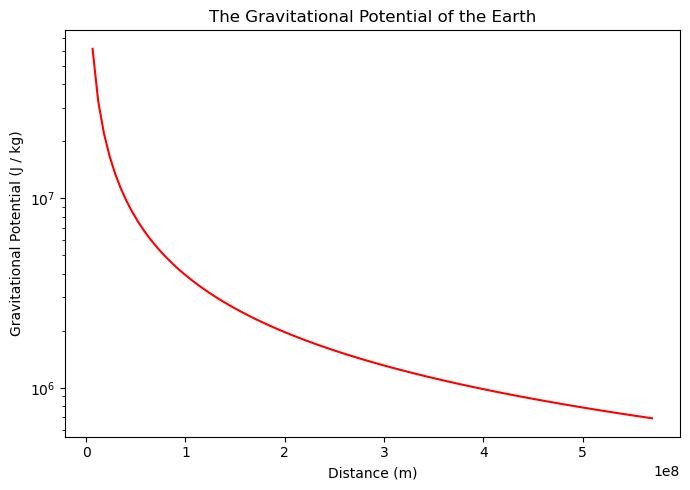

In [4]:
# Create distance array to store x values from the surface of the Earth to 1.5 * the distance from the Earth to the Moon
nstep = 100
x_vals = np.linspace(R_E, 1.5 * d_EM, nstep)

# Create array of y values
y_vals = np.zeros(nstep)


# Capture the gravitational potential values by calling the grav_potential() function
grav_pots = grav_potential(M_E, 0, 0, x_vals, y_vals)

# Capture the absolute values of the gravitational potential values
grav_pots = -grav_pots

# Plot the x and y arrays
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(x_vals, grav_pots, "red")
ax.set_yscale("log")
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Gravitational Potential (J / kg)")
ax.set_title("The Gravitational Potential of the Earth")
plt.tight_layout();

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

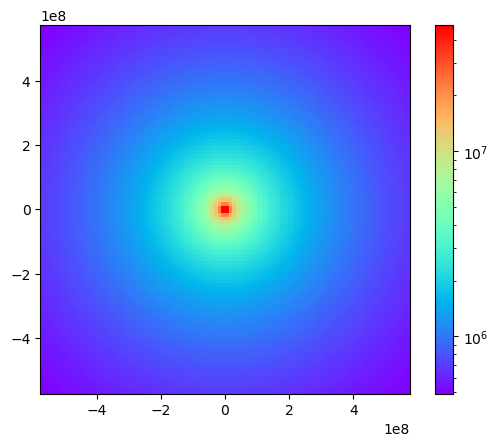

In [5]:
# Create distance array to store x and y values from +/-1.5 * the distance between the Earth and the Moon
nstep = 100
x_vals_15dEM = np.linspace(-1.5 * d_EM, 1.5 * d_EM, nstep)
y_vals_15dEM = np.linspace(-1.5 * d_EM, 1.5 * d_EM, nstep)


# Convert x and y arrays to grids
x_grid, y_grid = np.meshgrid(x_vals_15dEM, y_vals_15dEM)


# Capture the gravitational potential values by calling the grav_potential() function
z_grav_pot = grav_potential(M_E, 0, 0, x_grid, y_grid)
z_grav_pot = -z_grav_pot


# Capture the minimum and maximum gravitational potential values
vmin = np.amin(z_grav_pot)
vmax = np.amax(z_grav_pot)


# Create color-mesh plot
fig, ax = plt.subplots()
ax.set_aspect("equal")
mesh = ax.pcolormesh(x_grid, y_grid, z_grav_pot, cmap = 'rainbow', norm = colors.LogNorm(vmin = vmin, vmax = vmax))
cbar = fig.colorbar(mesh)

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

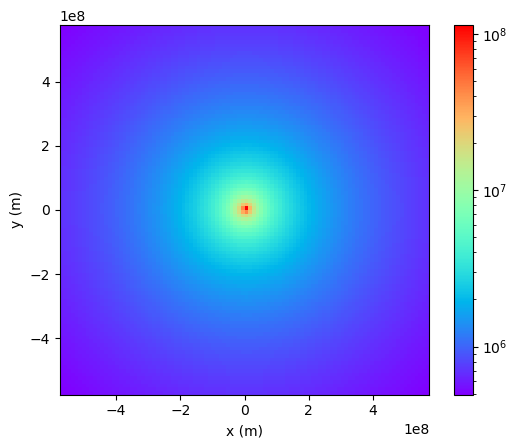

In [6]:
# Create variables to store Earth coordinates
x_Earth = 0
y_Earth = 0


# Create variables to store Moon coordinates
x_Moon = d_EM / np.sqrt(2)
y_Moon = d_EM / np.sqrt(2)


# Create variable to store the total mass of the combined Earth-Moon system
m_EM = M_E + M_M


# Create variable to store the center of mass coordinate for the Earth-Moon system
x_EM = ((M_E * x_Earth) + (M_M * x_Moon)) / m_EM
y_EM = ((M_E * y_Earth) + (M_M * y_Moon)) / m_EM


# Capture the gravitational potential values by calling the grav_potential() function
z_grav_pot_EM = grav_potential(m_EM, x_EM, y_EM, x_grid, y_grid)
z_grav_pot_EM = -z_grav_pot_EM


# Capture the minimum and maximum gravitational potential values
vmin_EM = np.amin(z_grav_pot_EM)
vmax_EM = np.amax(z_grav_pot_EM)


# Create color-mesh plot
fig, ax = plt.subplots()
ax.set_aspect("equal")
mesh = ax.pcolormesh(x_grid, y_grid, z_grav_pot_EM, cmap = 'rainbow', norm = colors.LogNorm(vmin = vmin_EM, vmax = vmax_EM))
cbar = fig.colorbar(mesh)
ax.set_xlabel("x (m)", fontsize = 10)
ax.set_ylabel("y (m)", fontsize = 10);

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

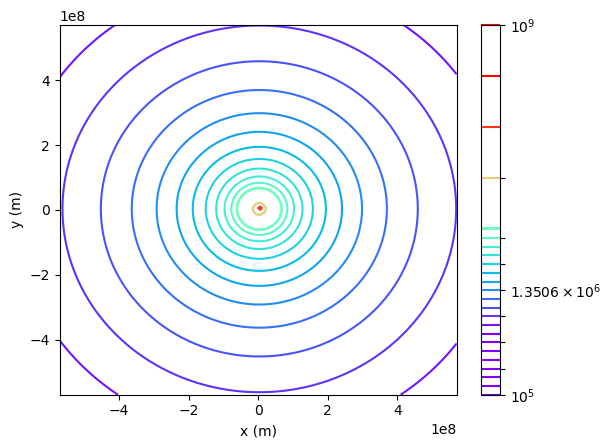

In [7]:
# Create 2D contour plot
levels = np.logspace(5, 6.79, num = 20)
levels = np.append(levels, np.logspace(6.8, 9, num = 5))
fig, ax = plt.subplots()
contour = ax.contour(x_grid, y_grid, z_grav_pot_EM, levels, cmap = "rainbow", norm = colors.LogNorm(vmin = vmin_EM, vmax = vmax_EM))
bar = fig.colorbar(contour)
ax.set_xlabel("x (m)", fontsize = 10)
ax.set_ylabel("y (m)", fontsize = 10);

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [14]:
# Create function
def grav_force(M1, m2, x1, y1, x2, y2):
    """
    A function which calculates the two gravitational force components, Fx and Fy, experienced by the
    mass m2 from the force exerted by M1

    Args:
        M1 (float): the mass of a body
        m2 (float): the mass of a secondary body
        x1 (float): the x-coordinate of the cartesian location of the first mass
        y1 (float): the y-coordinate of the cartesian location of the first mass
        x2 (float): the x-coordinate of the cartesian location of the second body
        y2 (float): the y-coordinate of the cartesian location of the second body

    Returns:
        Fx (float): the x component of the gravitation force experienced by the mass m2 from the force exerted by M1
        Fy (float): the y component of the gravitation force experiences by the mass m2 from the force exerted by M1
    """

    if not isinstance(M1, float) and not isinstance(M1, int):
        raise TypeError(f"Input for M1 is of the wrong type!")
        
    if not isinstance(m2, float) and not isinstance(m2, int):
        raise TypeError(f"Input for x_M is of the wrong type!")
        
    if not isinstance(x1, float) and not isinstance(x1, int) and not isinstance(x1, np.ndarrya):
        raise TypeError(f"Input for x1 is of the wrong type!")
        
    if not isinstance(y1, float) and not isinstance(y1, int) and not isinstance(y1, np.ndarray):
        raise TypeError(f"Input for y1 is of the wrong type!")
        
    if not isinstance(x2, float) and not isinstance(x2, int) and not isinstance(x2, np.ndarray):
        raise TypeError(f"Input for x2 is of the wrong type!")
        
    if not isinstance(y2, float) and not isinstance(y2, int) and not isinstance(y2, np.ndarray):
        raise TypeError(f"Input for y2 is of the wrong type!")

    if np.isclose(x1, x2.any()) and np.isclose(y1, y2.any()):
        Fx = np.nan
        Fy = np.nan
        
    else:
        Fx = (-G) * ((M1 * m2) / ((abs(x2 - x1))**2))
        Fy = (-G) * ((M1 * m2) / ((abs(y2 - y1))**2))

        assert isinstance(Fx, float) or isinstance(Fx, np.ndarray), "x component of gravitational force is not a float!"
        assert isinstance(Fy, float) or isinstance(Fy, np.ndarray), "y component of gravitational force is not a float!" 
        
    return Fx, Fy

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

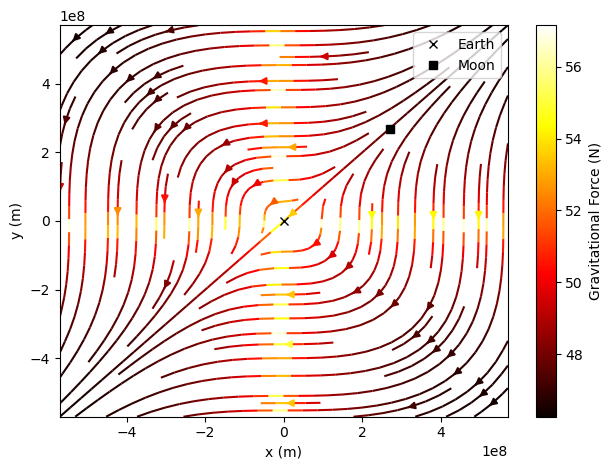

In [22]:
import matplotlib.cm as cm
# Create vector components
FX, FY = grav_force(M_E, M_M, x_EM, y_EM, x_grid, y_grid)


# Create scale for colors
colors = np.log(np.hypot(FX, FY))


# Create streamplot
fig, ax = plt.subplots()
stream = ax.streamplot(x_grid, y_grid, FX, FY, color = colors, cmap = cm.hot)
ax.set_xlabel("x (m)", fontsize = 10)
ax.set_ylabel("y (m)", fontsize = 10)
cbar = fig.colorbar(stream.lines, label = "Gravitational Force (N)")
ax.plot(x_Earth, y_Earth, "kx", label = "Earth")
ax.plot(x_Moon, y_Moon, "ks", label = "Moon")
plt.legend()
plt.tight_layout();

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

**State given formulas** \
$F_{Moon} = -G\frac{M_{Moon}m}{|r_{Mm}|^{2}}$ \
$F_{Earth} = -G\frac{M_{Earth}m}{|r_{Em}|^{2}}$

**Set gravitational forces due to the Earth and the Moon equal to each other** \
$|F_{Moon}| = |F_{Earth}|$ \
$-G\frac{M_{Moon}m}{|r_{Mm}|^{2}} = -G\frac{M_{Earth}m}{|r_{Em}|^{2}}$ \
$\frac{M_{M}}{|r_{Mm}|^{2}} = \frac{M_{E}}{|r_{Em}|^{2}}$ \
$M_{M}|r_{Em}|^{2} = M_{E}|r_{Mm}|^{2}$ \
$|r_{Em}|\sqrt{M_{M}} = |r_{Mm}|\sqrt{M_{E}}$ \
$|r_{Mm}| = |r_{Em}|\sqrt{\frac{M_{M}}{M_{E}}}$

**Set radial distances equal to the distance between the Earth and the Moon** \
$|r_{Em}| + |r_{Mm}| = d_{EM}$ \
$|r_{Em}| + |r_{Em}|\sqrt{\frac{M_{M}}{M_{E}}} = d_{EM}$ \
$|r_{Em}|(1 + \sqrt{\frac{M_{M}}{M_{E}}}) = d_{EM}$ \
$|r_{Em}| = \frac{d_{EM}}{1 + \sqrt{\frac{M_{M}}{M_{E}}}}$ \
$|r_{Em}| \approx 341962346.91181517 m$

**Find x and y components of radial distance** \
$|x| = |y|$ \
$x^{2} + y^{2} = |r_{Em}|^{2}$ \
$x^{2} + x^{2} = |r_{Em}|^{2}$ \
$2x^{2} = |r_{Em}|^{2}$ \
$\sqrt{2x^{2}} = |r_{Em}|$ \
$x\sqrt{2} = |r_{Em}|$ \
$x = \frac{|r_{Em}|}{\sqrt{2}}$ \
$x \approx 241803894.4118111 m$

And your updated plot, including the balance point, goes in the cell below.

Radial distance of the balance point to the moon:  341962346.91181517  meters
x and y components of radial distance:  241803894.4118111  meters
Distance from the balance point to the Moon: 38037653.08818483 meters


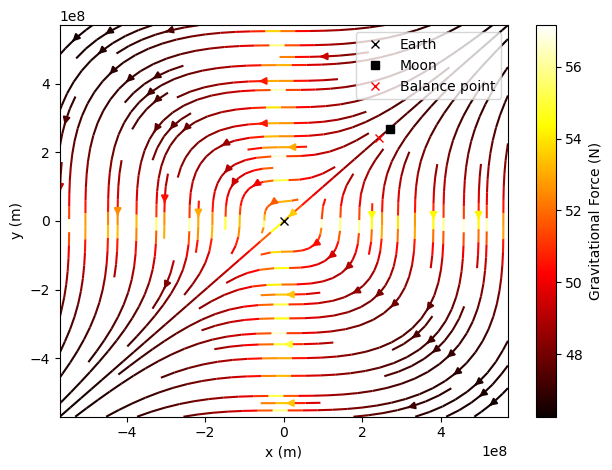

In [37]:
# Create variables to store the x and y coordinates of the balance point
distance_radial = d_EM / (1 + np.sqrt(M_M / M_E))
print("Radial distance of the balance point to the moon: ", distance_radial, " meters")
distance_component = distance_radial / np.sqrt(2)
print("x and y components of radial distance: ", distance_component, " meters")


# Calculate the distance from the balance point to the Moon
print(f"Distance from the balance point to the Moon: {d_EM - distance_radial} meters")

# Create new streamplot
fig, ax = plt.subplots()
stream = ax.streamplot(x_grid, y_grid, FX, FY, color = colors, cmap = cm.hot)
ax.set_xlabel("x (m)", fontsize = 10)
ax.set_ylabel("y (m)", fontsize = 10)
cbar = fig.colorbar(stream.lines, label = "Gravitational Force (N)")
ax.plot(x_Earth, y_Earth, "kx", label = "Earth")
ax.plot(x_Moon, y_Moon, "ks", label = "Moon")
ax.plot(distance_component, distance_component, "rx", label = "Balance point")
plt.legend()
plt.tight_layout()

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

The balance point is closer to the Moon. The balance point is $341962346.91181517$  meters away from the Earth but $38037653.08818483$ meters away from the Moon. This does make sense because the Earth is much more massive than the Moon, meaning that in order for the gravitational force from the Moon to cancel out that of the Earth, a given mass must be closer to the Moon since the gravitational force scales as $\frac{1}{r^{2}}$.

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

In [39]:
g = 9.81    # Gravitational Acceleration (m s^-2)
M_ACM = 5500    # Mass of Apollo Command Module (kg)
v_e = 2.4 * (10**3)    # Exhaust Velocity of Saturn V Stage 1 (S-1C) (m s^-1)
m_b = 1.3 * (10**4)    # Burn Rate of S-1C (kg s^-1)
m_0 = 2.8 * (10**6)    # Wet Mass of S-1C (kg)
m_f = 7.5 * (10**5)    # Dry Mass of S-1C (kg)

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [42]:
# Calculate the burn time T for the first stage of the new Saturn V rocket
T = (m_0 - m_f) / m_b
print(f"Burn time for the first stage of the new Saturn V rocket that NASA is planning to use to carry the Apollo capsule: {T} s")

Burn time for the first stage of the new Saturn V rocket that NASA is planning to use to carry the Apollo capsule: 157.69230769230768 s


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

[0.00000000e+00 3.33333420e+00 6.96868548e+00 1.09129458e+01
 1.51732457e+01 1.97569656e+01 2.46717474e+01 2.99255072e+01
 3.55264482e+01 4.14830755e+01 4.78042101e+01 5.44990056e+01
 6.15769647e+01 6.90479572e+01 7.69222394e+01 8.52104742e+01
 9.39237530e+01 1.03073619e+02 1.12672093e+02 1.22731698e+02
 1.33265490e+02 1.44287085e+02 1.55810697e+02 1.67851169e+02
 1.80424012e+02 1.93545447e+02 2.07232447e+02 2.21502785e+02
 2.36375085e+02 2.51868879e+02 2.68004662e+02 2.84803964e+02
 3.02289413e+02 3.20484817e+02 3.39415244e+02 3.59107114e+02
 3.79588296e+02 4.00888221e+02 4.23037994e+02 4.46070528e+02
 4.70020687e+02 4.94925441e+02 5.20824041e+02 5.47758207e+02
 5.75772347e+02 6.04913785e+02 6.35233026e+02 6.66784047e+02
 6.99624623e+02 7.33816692e+02 7.69426764e+02 8.06526383e+02
 8.45192646e+02 8.85508799e+02 9.27564900e+02 9.71458593e+02
 1.01729597e+03 1.06519261e+03 1.11527467e+03 1.16768032e+03
 1.22256124e+03 1.28008444e+03 1.34043447e+03 1.40381589e+03
 1.47045630e+03 1.540609

/var/folders/3b/789l72m9643gs0_pfrmg613w0000gn/T/ipykernel_74816/3235120886.py:4: RuntimeWarning: invalid value encountered in log
  delta_v = ((exhaust_speed) * (np.log((wet_mass) / (m_t)))) - (grav_constant * time)


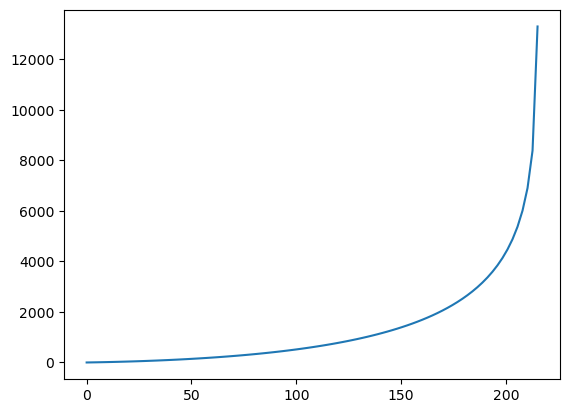

In [64]:
# Create function
def delta_vel(time, wet_mass, dry_mass, burn_rate, exhaust_speed, grav_constant):
    m_t = m_0 - ((m_b) * (time))
    delta_v = ((exhaust_speed) * (np.log((wet_mass) / (m_t)))) - (grav_constant * time)
    return delta_v


# Create array to store time values
times = np.linspace(0, 1.5 * T, 100)


# Capture the change in velocity array by calling the delta_v() function
delta_velocity = delta_vel(times, m_0, m_f, m_b, v_e, g)
print(delta_velocity)

plt.plot(times, delta_velocity)

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [66]:
# Calculate and print the altitude of the rocket at the end of the burn
h, error_h = spi.quad(lambda x: ((v_e) * (np.log((m_0) / ((m_0 - (m_b *x)))))) - (g * x), 0, T)
print(f"Altitude: {h} meters \nError: {error_h} meters")
print(f"Altitude: {h / (10**3)} km \nError: {error_h / (10**3)} km")

Altitude: 74093.98013366401 meters 
Error: 5.848811185394151e-08 meters
Altitude: 74.093980133664 km 
Error: 5.848811185394152e-11 km


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

The values calculated were $T \approx {157.69230769230768}$ seconds and $h \approx {74.093980133664}$ km. This means that the burn time calculation was an underestimate and the altitude was an overestimate. The simplification of neglecting drag could have contributed to the altitude estimation, seeing as drag would pull the rocket back toward the Earth and thus decreasing the maximum height. 